In [ ]:
from google.colab import drive

In [ ]:
pip install pycairo

In [ ]:
import pandas as pd
import string
import numpy as np

import cairo


import sys
import argparse
import copy
import math
import random
from textblob  import  TextBlob
from IPython.display import Image, display



In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Path to your file (adjust the path if needed)
file_path = '/content/drive/MyDrive/watchtower_lyrics.csv'

# Load the CSV
data = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
data.head()

,lyric
0,"There must be some kind of way out of here,"
1,"Said the joker to the thief,"
2,"There's too much confusion,"
3,"I can't get no relief,"
4,"Businessmen, they drink my wine,"


In [ ]:
pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

In [29]:
data['polarity'] = data['lyric'].apply(pol)
data['subjectivity'] = data['lyric'].apply(sub)
data['totalwords'] = data['lyric'].str.split().str.len()
data['pol_score'] = data['polarity'] * data['totalwords']


data['polarity'] = data['polarity'].astype(float)

def process(row):
            polarity = row['polarity']
            if polarity >0: return "0, 153, 0" #green
            if polarity ==0: return "0, 102, 255" #blue
            if polarity  <0: return "255, 0, 0" #red

data['colour'] = data.apply(process,axis=1)

color_map = {
    "0, 153, 0": "green",
    "0, 102, 255": "blue",
    "255, 0, 0": "red"
}

data['colour_name'] = data['colour'].map(color_map)

#data['colour'] = pd.to_numeric(data['colour'])


In [30]:

data = pd.DataFrame(data)
data.head(30)

,lyric,polarity,subjectivity,totalwords,pol_score,colour,rgb,colour_name
0,"There must be some kind of way out of here,",0.600,0.900,10,6.000,"0, 153, 0","(0.0, 0.6, 0.0)",green
1,"Said the joker to the thief,",0.000,0.000,6,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
2,"There's too much confusion,",0.200,0.200,4,0.800,"0, 153, 0","(0.0, 0.6, 0.0)",green
3,"I can't get no relief,",0.000,0.000,5,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
4,"Businessmen, they drink my wine,",0.000,0.000,5,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
5,"Plowmen dig my earth,",0.000,0.000,4,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
6,"None will level on the line,",0.000,0.000,6,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
7,"Nobody offered his word,",0.000,0.000,4,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
8,"Hey!,",0.000,0.000,1,0.000,"0, 102, 255","(0.0, 0.4, 1.0)",blue
9,"No reason to get excited,",0.375,0.750,5,1.875,"0, 153, 0","(0.0, 0.6, 0.0)",green


In [ ]:
data['rgb'] = data['colour'].apply(
    lambda x: tuple(int(c)/255 for c in x.split(', '))
)

In [ ]:
params = {
    "width": 1000,
    "height": 1000,
    "initial": 120,
    "deviation": 50,
    "basedeforms": 1,
    "finaldeforms": 3,
    "minshapes": 20,
    "maxshapes": 25,
    "shapealpha": 0.02
}

In [ ]:
for idx, row in data.iterrows():
    print(idx, row['pol_score'], row['rgb'])


0 6.0 (0.0, 0.6, 0.0)
1 0.0 (0.0, 0.4, 1.0)
2 0.8 (0.0, 0.6, 0.0)
3 0.0 (0.0, 0.4, 1.0)
4 0.0 (0.0, 0.4, 1.0)
5 0.0 (0.0, 0.4, 1.0)
6 0.0 (0.0, 0.4, 1.0)
7 0.0 (0.0, 0.4, 1.0)
8 0.0 (0.0, 0.4, 1.0)
9 1.875 (0.0, 0.6, 0.0)
10 3.0 (0.0, 0.6, 0.0)
11 3.0 (0.0, 0.6, 0.0)
12 0.0 (0.0, 0.4, 1.0)
13 0.0 (0.0, 0.4, 1.0)
14 0.0 (0.0, 0.4, 1.0)
15 -2.8000000000000007 (1.0, 0.0, 0.0)
16 -1.2 (1.0, 0.0, 0.0)
17 0.0 (0.0, 0.4, 1.0)
18 0.0 (0.0, 0.4, 1.0)
19 0.0 (0.0, 0.4, 1.0)
20 0.0 (0.0, 0.4, 1.0)
21 0.0 (0.0, 0.4, 1.0)
22 -1.5 (1.0, 0.0, 0.0)
23 0.0 (0.0, 0.4, 1.0)
24 0.0 (0.0, 0.4, 1.0)
25 0.0 (0.0, 0.4, 1.0)
26 0.0 (0.0, 0.4, 1.0)
27 0.0 (0.0, 0.4, 1.0)


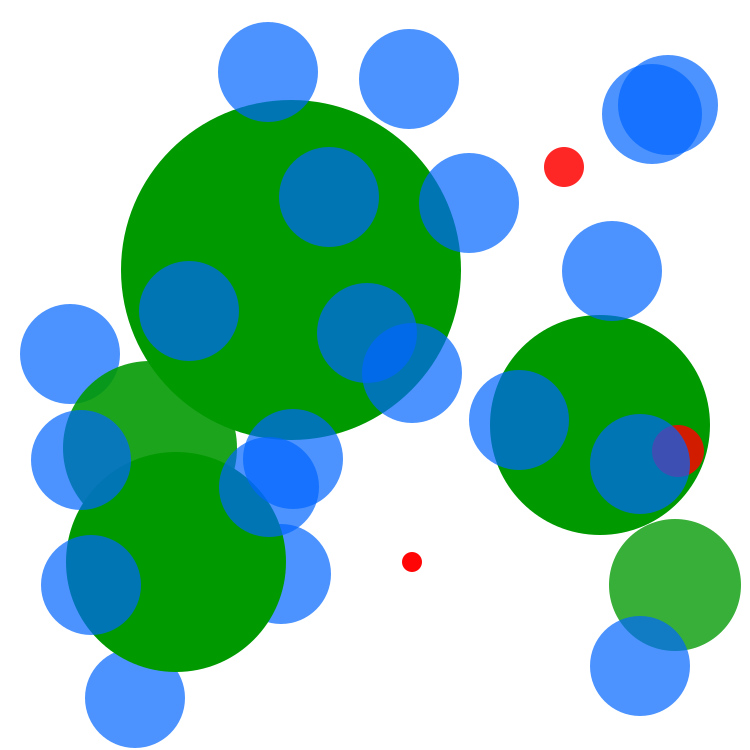

In [ ]:
# data = pd.read_csv('/content/drive/MyDrive/watchtower_lyrics.csv')

# 2. Parse colour strings into normalized RGB
data['rgb'] = data['colour'].apply(
    lambda x: tuple(int(c)/255 for c in x.split(', '))
)

# 3. Map score → shape size
def score_to_size(score, base=50, scale=20):
    return max(10, base + int(score * scale))

# 4. Create a canvas
WIDTH, HEIGHT = 750, 750
ims = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
cr = cairo.Context(ims)

# White background
cr.set_source_rgb(1, 1, 1)
cr.paint()

# 5. Draw shapes row by row
for idx, row in data.iterrows():
    x = random.randint(50, WIDTH-50)
    y = random.randint(50, HEIGHT-50)

    size = score_to_size(row['pol_score'])
    r, g, b = row['rgb']

    shapealpha = 0.7 + (abs(row['pol_score'])/10)  # optional: tie opacity to pol_score
    shapealpha = min(1.0, shapealpha)  # cap at 1.0

    cr.set_source_rgba(r, g, b, shapealpha)

    cr.arc(x, y, size, 0, 2*math.pi)
    cr.fill()

# 6. Save result
output_path = "/content/drive/MyDrive/lyrics_shapes.png"
ims.write_to_png(output_path)

display(Image(output_path))